#### Excercise
##### Monthly Job Demand:
<div style='font-size:14px'>We will inspect what is the demand of certain job titles over the course of a year 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

In [4]:
df_India = df[df['job_country']=='India'].copy()

<div style='font-size:14px'>now we need to extract months from job posted date but nott numbers we want january feb etc.    Here we used %B which means Month as locale's full name. we can also see more codes like this in the documentation 

In [5]:
df_India['job_posted_month'] = df_India['job_posted_date'].dt.strftime('%B')

In [6]:
df_India_pivot = df_India.pivot_table(
    index= 'job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)

<div style='font-size:14px'> now this output is in alphabetical order but its of no use cz we want o/p as jan,feb,march...etc so we need to assign a no. to each month in order to rearrange them

In [8]:
df_India_pivot.reset_index(inplace = True)
df_India_pivot

job_title_short,index,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,0,April,170,32,418,1566,946,54,86,375,194,169
1,1,August,189,25,618,1407,1157,47,126,343,235,148
2,2,December,186,27,648,1464,1206,94,77,343,200,133
3,3,February,143,35,433,1631,932,42,94,313,165,157
4,4,January,175,31,628,2132,1444,70,127,448,269,192
5,5,July,142,25,457,1528,1123,54,75,359,204,155
6,6,June,146,26,367,1632,1129,41,66,427,238,125
7,7,March,116,37,422,1591,1005,34,96,351,194,180
8,8,May,103,14,278,1384,837,31,59,329,134,98
9,9,November,192,29,722,1743,1614,52,125,423,278,139


In [40]:
df_India_pivot['month_no']= pd.to_datetime(df_India_pivot['job_posted_month'], format='%B').dt.month

df_India_pivot['month_no']

0      4
1      8
2     12
3      2
4      1
5      7
6      6
7      3
8      5
9     11
10    10
11     9
Name: month_no, dtype: int32

In [ ]:
df_India_pivot.sort_values('month_no',inplace= True)
df_India_pivot.set_index('job_posted_month',inplace=True)


In [44]:
df_India_pivot.drop(columns=['month_no'],inplace= True)

<Axes: xlabel='job_posted_month'>

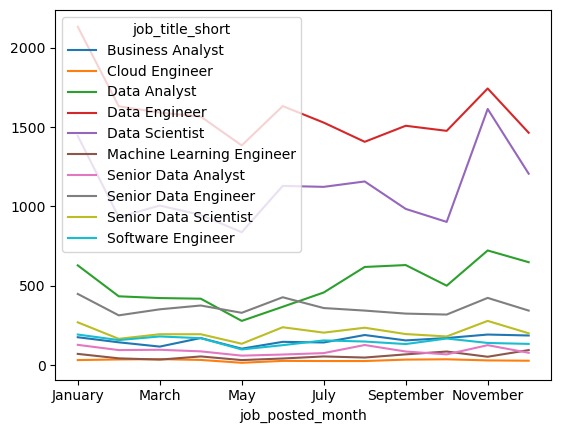

In [47]:
df_India_pivot.plot(kind='line')


In [52]:
top_3=df_India['job_title_short'].value_counts().head(3)
top_3 = top_3.index.tolist()

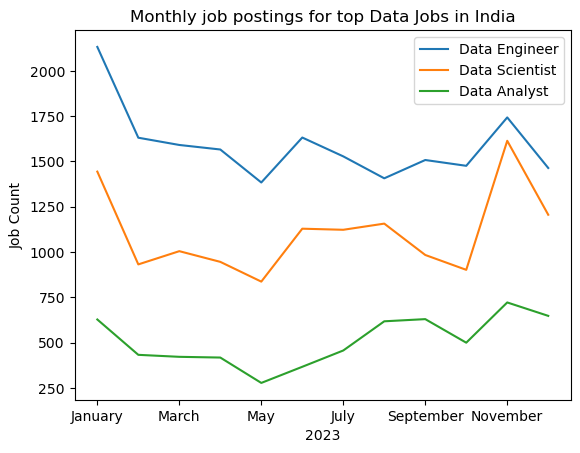

In [55]:
df_India_pivot[top_3].plot(kind='line')
plt.title('Monthly job postings for top Data Jobs in India')
plt.ylabel('Job Count')
plt.xlabel('2023')
plt.legend()